# Deep05. Attention 기반 Seq2seq 한영 번역기

`korean-english-park` 병렬 말뭉치로 **Bahdanau Attention 기반 Seq2seq 번역기**를 만든다.

## 루브릭

| 학습목표 | 평가기준 | 
|---|---|
| 1. 번역기 모델 학습에 필요한 텍스트 데이터 전처리가 한국어 포함하여 잘 이루어졌다. | 구두점, 대소문자, 띄어쓰기, 한글 형태소분석 등 번역기 모델에 요구되는 전처리가 정상적으로 진행되었다. |
| 2. Attentional Seq2seq 모델이 정상적으로 구동된다. | seq2seq 모델 훈련 과정에서 training loss가 안정적으로 떨어지면서 학습이 진행됨이 확인되었다. |
| 3. 테스트 결과 의미가 통하는 수준의 번역문이 생성되었다. | 테스트용 디코더 모델이 정상적으로 만들어져서, 정답과 어느 정도 유사한 영어 번역이 진행됨을 확인하였다. |


## 진행 순서

```
 1. 환경 · 라이브러리 · 한글 폰트 · Mecab 준비
 2. 데이터 로드 & EDA
 3. 데이터 정제 (1) — 중복 제거 → cleaned_corpus
 4. 데이터 정제 (2) — 언어별 정규식 전처리
 5. 토큰화 & 길이 필터 → kor_corpus / eng_corpus
 6. tokenize() — 텐서 변환 & Vocabulary 결정
 7. 모델 설계 — Encoder / BahdanauAttention / Decoder
 8. 훈련 준비 — Optimizer & Loss & train_step
 9. 훈련 실행 + 매 epoch 예문 번역
10. 실험
11. 최종 결과
12. 회고
```

## 실행 플로우

```
[ 원본 ]  korean-english-park.train.ko / .en   (94,123 쌍)
                          |
                          v
[ 3 ]  set 기반 중복 제거 (zip 순회, 쌍 유지)      ->  cleaned_corpus  (77,591 쌍)
                          |
                          v
[ 4 ]  노이즈 패턴 제거  보일러플레이트 / 제목줄 / 어휘풀이 / 한글0자 / 소스=타깃
                          |
          +---------------+-----------------+
          v (한국어)                          v (영어)
        라틴문자 소문자화                     소문자화
        곡선 따옴표 -> ASCII                  곡선 따옴표 -> ASCII
        숫자 내부 . , 보호                    숫자 내부 . , 보호
        구두점 분리  ? . ! ,                  구두점 분리  ? . ! ,
        [^가-힣a-z0-9?.!,'] -> 공백           contractions 정규화
        다중 공백 축소                        [^a-z0-9?.!,'] -> 공백 / 공백 축소
          |                                   |
          v                                   v
[ 5 ]  Mecab.morphs() -> 공백 결합           (그대로)
          |                                   |
          +---------------+-------------------+
                          v
              SentencePiece 학습  vocab 16,000 · pad0 bos1 eos2 unk3
                          |
                          v
              encode -> id       영어만 [bos] ... [eos] 부착
                          |
                          v
              양쪽 모두 길이 <= 40 인 쌍만 선별
                          |
                          v
              kor_corpus / eng_corpus
                          |
                          v
[ 6 ]  post-padding -> src / trg_input / trg_label   (N, 40) LongTensor
                          |
                          v
              TensorDataset -> DataLoader (batch 64)
                          |
                          v
[ 7 ]  Encoder(GRU) -> encoder_outputs, hidden
                     -> BahdanauAttention -> context
                     -> Decoder(GRU) -> prediction, hidden, attention
                          |
                          v
[ 8~9 ] Adam(1e-3) + CrossEntropyLoss(ignore_index=0) + clip_grad_norm(1.0)
         train_step() 만 사용 (eval_step 없음) — 훈련/검증 분리하지 않음
         매 epoch 예문 4개 번역 + 체크포인트 저장
```

---
# 1. 환경 · 라이브러리 · 한글 폰트 · Mecab 준비

### 1-1. 라이브러리

In [35]:
import os
import re
import time
import random
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import sentencepiece as spm
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

# ---- 경로 ----
BASE_DIR = os.path.abspath('')
DATA_DIR = os.path.join(BASE_DIR, 'data')
KOR_PATH = os.path.join(DATA_DIR, 'korean-english-park.train.ko')
ENG_PATH = os.path.join(DATA_DIR, 'korean-english-park.train.en')

# ---- 시드 ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('[ 환경 ]')
print(f'torch       : {torch.__version__}')
print(f'device      : {device}')
print(f'데이터 경로  : {DATA_DIR}')

[ 환경 ]
torch       : 2.11.0+cu128
device      : cuda
데이터 경로  : C:\Aiffel\AIFFEL_quest_rs\GoingDeeper\Deep05\data


### 1-2. matplotlib 한글 폰트

In [2]:
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# Windows 기본 한글 폰트(맑은 고딕). 없으면 설치된 한글 폰트를 자동으로 찾아 사용한다.
installed = {f.name for f in fm.fontManager.ttflist}
for candidate in ["Malgun Gothic", "NanumBarunGothic", "NanumGothic", "AppleGothic"]:
    if candidate in installed:
        font_name = candidate
        break
else:
    font_name = plt.rcParams["font.family"][0]
    print("한글 폰트를 찾지 못했습니다. Attention Map의 한글이 깨질 수 있습니다.")

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False  # 한글 폰트 사용 시 마이너스 기호 깨짐 방지

print(f"설정된 폰트: {font_name}")

설정된 폰트: Malgun Gothic


### 1-3. 한국어 형태소 분석기

아래 셀을 실행하여 Windows용 휠(`mecab_ko-1.0.2-cp312-cp312-win_amd64`)을 설치한다.
설치 후에는 커널을 재시작해야 한다.

In [3]:
# !pip install mecab-ko mecab-ko-dic

In [4]:
def get_ko_tokenizer():
    """한국어 형태소 분석기를 확보하고 (morphs 함수, 이름) 을 돌려준다.

    Windows 에서는 MeCab 바이너리를 찾지 못해 실패하는 경우가 많다. 
    아래 순서로 시도하고, 성공한 경로를 이름과 함께 반환한다.

        1) konlpy.tag.Mecab   : 명세가 요구하는 1순위
        2) mecab_ko           : 같은 MeCab-ko 엔진. konlpy 래퍼만 우회한다
        3) kiwipiepy.Kiwi     : 이미 설치되어 있는 최후 보루
    """
    # ---- 1) KoNLPy Mecab ----
    try:
        from konlpy.tag import Mecab
        tagger = Mecab()
        tagger.morphs('테스트')
        return tagger.morphs, 'konlpy.tag.Mecab'
    except Exception as e:
        print(f'[1] konlpy.tag.Mecab  사용 불가 -> {type(e).__name__}: {e}')

    # ---- 2) mecab-ko 패키지 직접 사용 ----
    try:
        import mecab_ko
        try:
            tagger = mecab_ko.MeCab()
            tagger.morphs('테스트')
            return tagger.morphs, 'mecab_ko.MeCab'
        except AttributeError:
            pass

        try:
            tagger = mecab_ko.Tagger()
        except Exception:
            import mecab_ko_dic
            tagger = mecab_ko.Tagger(mecab_ko_dic.MECAB_ARGS)

        def morphs(text):
            # parse() 는 "표층형\t품사정보" 줄들을 내놓고 마지막에 EOS 가 붙는다.
            return [line.split('\t')[0] for line in tagger.parse(text).splitlines()
                    if line and line != 'EOS']

        morphs('테스트')
        return morphs, 'mecab_ko.Tagger'
    except Exception as e:
        print(f'[2] mecab_ko          사용 불가 -> {type(e).__name__}: {e}')

    # ---- 3) Kiwi ----
    try:
        from kiwipiepy import Kiwi
        kiwi = Kiwi()

        def morphs(text):
            return [t.form for t in kiwi.tokenize(text)]

        morphs('테스트')
        return morphs, 'kiwipiepy.Kiwi'
    except Exception as e:
        print(f'[3] kiwipiepy.Kiwi    사용 불가 -> {type(e).__name__}: {e}')

    raise RuntimeError('사용 가능한 형태소 분석기가 없습니다. pip install mecab-ko mecab-ko-dic')


ko_morphs, KO_TOKENIZER_NAME = get_ko_tokenizer()

print(f'\n>> 사용 분석기 : {KO_TOKENIZER_NAME}')
for s in ['오바마는 대통령이다.', '일곱 명의 사망자가 발생했다.']:
    print(f'   {s}  ->  {ko_morphs(s)}')

[1] konlpy.tag.Mecab  사용 불가 -> Exception: Install MeCab in order to use it: http://konlpy.org/en/latest/install/

>> 사용 분석기 : mecab_ko.Tagger
   오바마는 대통령이다.  ->  ['오바마', '는', '대통령', '이', '다', '.']
   일곱 명의 사망자가 발생했다.  ->  ['일곱', '명', '의', '사망자', '가', '발생', '했', '다', '.']


---
# 2. 데이터 로드 & EDA

### 2-1. 데이터 로드 · len · 샘플 확인

In [5]:
with open(KOR_PATH, encoding='utf-8') as f:
    kor_lines = f.read().splitlines()
with open(ENG_PATH, encoding='utf-8') as f:
    eng_lines = f.read().splitlines()

print(f'한국어 개수 : {len(kor_lines):,}')
print(f'영어   개수 : {len(eng_lines):,}')
assert len(kor_lines) == len(eng_lines), '줄 수가 달라 병렬 쌍이 성립하지 않는다'

print('\n[ 샘플 5쌍 ]')
for i in range(5):
    print(f'  [{i}] KO : {kor_lines[i]}')
    print(f'      EN : {eng_lines[i]}')

한국어 개수 : 94,123
영어   개수 : 94,123

[ 샘플 5쌍 ]
  [0] KO : 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
      EN : Much of personal computing is about "can you top this?"
  [1] KO : 모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다.
      EN : so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable, wireless mouse.
  [2] KO : 그러나 이것은 또한 책상도 필요로 하지 않는다.
      EN : Like all optical mice, But it also doesn't need a desk.
  [3] KO : 79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분이든 그 움직임에따라 커서의 움직임을 조절하는 회전 운동 센서를 사용하고 있다.
      EN : uses gyroscopic sensors to control the cursor movement as you move your wrist, arm, whatever through the air.
  [4] KO : 정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔음을 밝혔으며, 세계 해상 교역량의 거의 3분의 1을 운송하는 좁은 해로인 말라카 해협이 테러 공격을 당하기 쉽다고 경고하고 있다.
      EN : Intelligence officials have revealed a spate of foiled plots on ships in Southeast Asia and are warning that a narrow stretch of water carrying almost one third of the world'

### 2-2. 중복

In [6]:
n_pair = len(kor_lines)
u_ko   = len(set(kor_lines))
u_en   = len(set(eng_lines))
u_both = len(set(zip(kor_lines, eng_lines)))

print(f'원본 쌍             : {n_pair:,}')
print(f'한국어 unique       : {u_ko:,}  ({u_ko / n_pair:.1%})')
print(f'영어   unique       : {u_en:,}  ({u_en / n_pair:.1%})')
print(f'(한국어, 영어) unique : {u_both:,}')

# 두 종류의 '중복'은 성격이 전혀 다르다 -> 3절의 제거 기준이 여기서 결정된다.
print(f'\n같은 한국어에 다른 영어 : {u_both - u_ko:,}건  (모순된 지도신호 -> 제거)')
print(f'다른 한국어에 같은 영어 : {u_both - u_en:,}건  (정상적인 many-to-one -> 유지)')

원본 쌍             : 94,123
한국어 unique       : 77,591  (82.4%)
영어   unique       : 75,598  (80.3%)
(한국어, 영어) unique : 78,968

같은 한국어에 다른 영어 : 1,377건  (모순된 지도신호 -> 제거)
다른 한국어에 같은 영어 : 3,370건  (정상적인 many-to-one -> 유지)


### 2-3. 길이 분포

길이 컷을 정하기 위해 길이 분포를 확인한다. 형태소 분석은 전량을 돌리면 오래 걸리므로 여기서는 **표본으로 추정**하고,
전량 분석은 이후 수행한다.

In [7]:
ko_ws = np.array([len(s.split()) for s in kor_lines])   # 한국어 공백 토큰 수
en_ws = np.array([len(s.split()) for s in eng_lines])   # 영어 공백 토큰 수

# 형태소 길이는 표본으로 추정한다.
SAMPLE_N = 5000
sample_idx = random.sample(range(n_pair), SAMPLE_N)
ko_mp = np.array([len(ko_morphs(kor_lines[i])) for i in tqdm(sample_idx, desc='형태소 분석(표본)')])
en_ws_sample = en_ws[sample_idx]


def describe(name, arr):
    return {'구분': name,
            'mean': round(float(arr.mean()), 1),
            'median': int(np.median(arr)),
            'p75': int(np.percentile(arr, 75)),
            'p90': int(np.percentile(arr, 90)),
            'max': int(arr.max())}


df_len = pd.DataFrame([
    describe('한국어 (공백)', ko_ws),
    describe('영어   (공백)', en_ws),
    describe(f'한국어 (형태소, 표본 {SAMPLE_N:,})', ko_mp),
    describe(f'영어   (공백+특수토큰 2, 표본 {SAMPLE_N:,})', en_ws_sample + 2),
])
display(df_len)

형태소 분석(표본): 100%|██████████| 5000/5000 [00:00<00:00, 5454.13it/s]


,구분,mean,median,p75,p90,max
0,한국어 (공백),14.0,14,18,23,82
1,영어 (공백),20.9,20,28,35,90
2,"한국어 (형태소, 표본 5,000)",29.1,28,38,48,93
3,"영어 (공백+특수토큰 2, 표본 5,000)",22.9,22,30,37,83


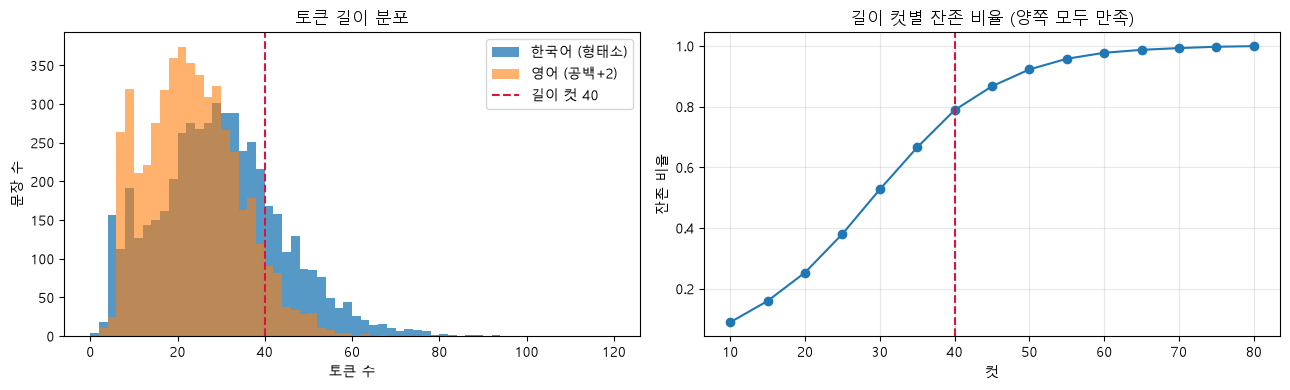

[ 길이 컷 후보 ]
   30 이하 -> 잔존  52.7%
   40 이하 -> 잔존  78.8%
   50 이하 -> 잔존  92.2%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(ko_mp, bins=60, range=(0, 120), alpha=.75, label='한국어 (형태소)')
axes[0].hist(en_ws_sample + 2, bins=60, range=(0, 120), alpha=.6, label='영어 (공백+2)')
axes[0].axvline(40, color='crimson', ls='--', lw=1.5, label='길이 컷 40')
axes[0].set_title('토큰 길이 분포')
axes[0].set_xlabel('토큰 수'); axes[0].set_ylabel('문장 수'); axes[0].legend()

# 길이 컷 후보별 잔존율
cuts = list(range(10, 81, 5))
keep = [((ko_mp <= c) & (en_ws_sample + 2 <= c)).mean() for c in cuts]
axes[1].plot(cuts, keep, marker='o')
axes[1].axvline(40, color='crimson', ls='--', lw=1.5)
axes[1].set_title('길이 컷별 잔존 비율 (양쪽 모두 만족)')
axes[1].set_xlabel('컷'); axes[1].set_ylabel('잔존 비율'); axes[1].grid(alpha=.3)

plt.tight_layout(); plt.show()

print('[ 길이 컷 후보 ]')
for c in (30, 40, 50):
    r = ((ko_mp <= c) & (en_ws_sample + 2 <= c)).mean()
    print(f'  {c:>3} 이하 -> 잔존 {r:6.1%}')

### 2-4. 길이비

길이비 `한국어 형태소 수 / 영어 단어 수`의 분포를 보고, 정렬이 어긋한 이상치를 확인한다.

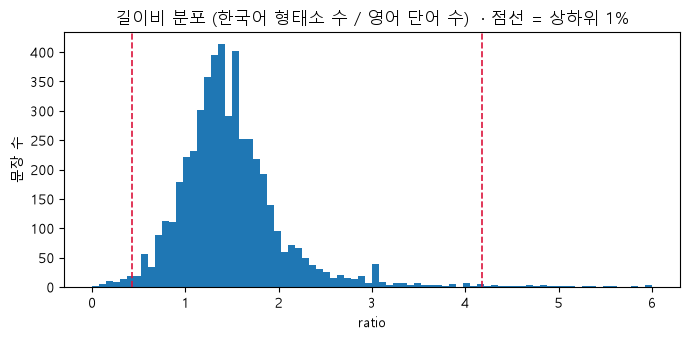


median 1.41 · p1 0.43 · p99 4.18

[ 길이비 상위 3건 — 한국어에 비해 영어가 지나치게 짧다 ]
  ratio  38.0  KO : (CNN)/ (JOINS) ##http://article.joins.com/article/cnn_e/article.asp?ca
                EN : ##http://article.joins.com/article/cnn_e/article.asp?cat_code=22&Total
  ratio  38.0  KO : (CNN)/ (JOINS) ##http://article.joins.com/article/cnn_e/article.asp?ca
                EN : ##http://article.joins.com/article/cnn_e/article.asp?cat_code=22&Total
  ratio  36.0  KO : South Carolina (CNN) ##http://article.joins.com/article/cnn_e/article.
                EN : ##http://article.joins.com/article/cnn_e/article.asp?cat_code=22&Total

[ 길이비 하위 3건 — 영어가 지나치게 길다 ]
  ratio  0.06  KO : 어휘 :
                EN : the United States will take every measure against what is perhaps grea
  ratio  0.07  KO : 번역 :
                EN : Two bandits shot dead Devi's gang leader lover and took her their vill
  ratio  0.09  KO : 한자사전
                EN : In response, an IAEA inspection team arrived in Korea on Aug.


In [9]:
ratio = ko_mp / np.maximum(en_ws_sample, 1)

plt.figure(figsize=(7, 3.5))
plt.hist(ratio, bins=80, range=(0, 6))
for q, c in [(1, 'crimson'), (99, 'crimson')]:
    plt.axvline(np.percentile(ratio, q), color=c, ls='--', lw=1.2)
plt.title('길이비 분포 (한국어 형태소 수 / 영어 단어 수)  · 점선 = 상하위 1%')
plt.xlabel('ratio'); plt.ylabel('문장 수')
plt.tight_layout(); plt.show()

print(f'\nmedian {np.median(ratio):.2f} · p1 {np.percentile(ratio, 1):.2f} · p99 {np.percentile(ratio, 99):.2f}')

print('\n[ 길이비 상위 3건 — 한국어에 비해 영어가 지나치게 짧다 ]')
for i in np.argsort(-ratio)[:3]:
    j = sample_idx[i]
    print(f'  ratio {ratio[i]:5.1f}  KO : {kor_lines[j][:70]}')
    print(f'                EN : {eng_lines[j][:70]}')

print('\n[ 길이비 하위 3건 — 영어가 지나치게 길다 ]')
for i in np.argsort(ratio)[:3]:
    j = sample_idx[i]
    print(f'  ratio {ratio[i]:5.2f}  KO : {kor_lines[j][:70]}')
    print(f'                EN : {eng_lines[j][:70]}')

### 2-5. 문자 종류 분포

한국어 쪽에 실제로 어떤 문자가 얼마나 섞여 있는지 계산한다.

In [10]:
KEEP_PUNCT = set('?.!,')


def char_class(ch):
    """한 글자를 4절 정규식의 판단 단위로 분류한다."""
    if '가' <= ch <= '힣':                 return '완성형 한글'
    if '\u3131' <= ch <= '\u318e':         return '한글 자모 (ㅋㅋ/ㅠㅠ)'
    if '\u4e00' <= ch <= '\u9fff':         return '한자'
    if '\u3040' <= ch <= '\u30ff':         return '일본어 가나'
    if ch.isascii() and ch.isalpha():      return '라틴 문자'
    if ch.isdigit():                       return '숫자'
    if ch in KEEP_PUNCT:                   return '보존 구두점 (?.!,)'
    return '기타 기호'


cls_counter = Counter()
etc_counter = Counter()
for s in kor_lines:
    for ch in s:
        if ch.isspace():
            continue
        c = char_class(ch)
        cls_counter[c] += 1
        if c == '기타 기호':
            etc_counter[ch] += 1

total = sum(cls_counter.values())
df_char = pd.DataFrame(
    [{'문자 종류': k, '개수': v, '비율': f'{v / total:.2%}'}
     for k, v in cls_counter.most_common()])
display(df_char)

# 4절에서 실제로 지워질 문자들이 무엇인지 눈으로 확인한다.
print('[ "기타 기호" 상위 30종 — 4절 제거 대상 ]')
print('  ' + '  '.join(f'{repr(ch)}x{n:,}' for ch, n in etc_counter.most_common(30)))

,문자 종류,개수,비율
0,완성형 한글,3916063,87.28%
1,라틴 문자,211969,4.72%
2,숫자,145420,3.24%
3,"보존 구두점 (?.!,)",122438,2.73%
4,기타 기호,88854,1.98%
5,한자,1825,0.04%
6,일본어 가나,74,0.00%
7,한글 자모 (ㅋㅋ/ㅠㅠ),7,0.00%


[ "기타 기호" 상위 30종 — 4절 제거 대상 ]
  '“'x14,002  '('x13,920  ')'x13,906  '”'x13,858  '"'x6,561  '’'x4,542  "'"x4,261  '‘'x3,541  '%'x2,714  '-'x2,696  '/'x1,586  '…'x1,189  '~'x990  '&'x787  ':'x709  '['x643  ']'x640  '='x423  '˝'x394  '_'x380  '#'x304  ';'x158  '`'x149  '*'x87  '·'x49  '•'x43  '´'x38  '▶'x31  '$'x21  '）'x20


### 2-6. EDA 정리

| 확인 항목 | 실행 결과 | 반영 |
|---|---|---|
| 형태소 분석기 | `konlpy.tag.Mecab` 실패 → **`mecab_ko.Tagger`** 사용 (동일 MeCab-ko 엔진 + mecab-ko-dic) | - |
| 줄 수 | `.ko` / `.en` 모두 94,123줄로 일치 | - |
| 중복 | 쌍 unique 78,968 · 한국어 77,591 · 영어 75,598<br>같은 한국어에 다른 영어 **1,377건** · 다른 한국어에 같은 영어 **3,370건** | 한국어 기준 제거 |
| 길이 (표본 5,000) | 한국어 형태소 mean 29.1 / median 28 / p90 48<br>영어 공백+2 mean 22.9 / median 22 / p90 37 | 길이 컷 |
| 길이 컷 잔존율 | 30 → 52.7% · **40 → 78.8%** · 50 → 92.2% | 컷 40 채택 |
| 길이비 | median 1.41 · p1 0.43 · p99 4.18<br>이상치는 `##http://...` 링크 줄과 `어휘 :` / `번역 :` / `한자사전` 메타 줄 | 패턴 제거 |
| 문자 종류 | 완성형 한글 87.28% · 라틴 4.72% · **숫자 3.24%** · `?.!,` 2.73% · 기타 기호 1.98% · 한자 0.04% · 가나 0.00% · 자모 7자 | 허용 집합 |

- 길이 통계는 **전처리 전 원본** 기준이며, 확정값은 §5에서 전량 재측정한다.
- 숫자(3.24%)는 한자(0.04%)·자모(7자)와 자릿수가 다르다. **숫자는 보존하고 한자·가나·자모·기타 기호만 제거한다.**

---
# 3. 데이터 정제 - (1) 중복 제거

**한국어 기준을 택한다.** 같은 인코더 입력에 서로 다른 정답이 붙어 있으면 모델은 어느 쪽으로도 수렴하지 못하고 두 답을 평균낸 듯한 문장을 뱉게 된다.

반대로 **다른 한국어에 같은 영어가 붙은 쌍은 지우지 않는다.**
여러 표현이 같은 영어로 번역되는 것은 정상적인 상황이고, 인코더가 다양한 표현을 같은 의미로 묶는 법을 배우는 데 오히려 도움이 된다.

In [11]:
def dedup_parallel(src_lines, trg_lines, key='src'):
    """병렬 쌍을 유지한 채 중복을 제거한다.

    set(src) / set(trg) 를 따로 만들면 개수도 순서도 달라져 대응 관계가 소실된다.
    zip 으로 함께 순회하면서 이미 본 문장이면 '쌍째로' 건너뛰어야 병렬성이 지켜진다.
    """
    seen = set()          # 중복 판정 전용
    kept = []
    for src, trg in zip(src_lines, trg_lines):
        k = src if key == 'src' else (src, trg)
        if k in seen:
            continue      # 쌍째로 통째 스킵 -> 대응 유지
        seen.add(k)
        kept.append((src, trg))
    return kept


cleaned_corpus = dedup_parallel(kor_lines, eng_lines, key='src')

print(f'중복 제거 전 : {len(kor_lines):,} 쌍')
print(f'중복 제거 후 : {len(cleaned_corpus):,} 쌍   ({1 - len(cleaned_corpus) / len(kor_lines):.1%} 감소)')

중복 제거 전 : 94,123 쌍
중복 제거 후 : 77,591 쌍   (17.6% 감소)


In [12]:
from collections import defaultdict

# 두 기준의 차이가 2-2에서 센 수치와 맞는가
by_pair = dedup_parallel(kor_lines, eng_lines, key='pair')
print(f'한국어 기준 : {len(cleaned_corpus):,} 쌍')
print(f'튜플   기준 : {len(by_pair):,} 쌍')
print(f'차이        : {len(by_pair) - len(cleaned_corpus):,} 쌍')
assert len(by_pair) - len(cleaned_corpus) == u_both - u_ko

# 버려지는 쌍이 실제로 어떻게 생겼는지 확인한다
multi = defaultdict(set)
for ko, en in zip(kor_lines, eng_lines):
    multi[ko].add(en)
multi = {k: v for k, v in multi.items() if len(v) > 1}

print(f'\n한국어 하나에 영어가 여러 개 붙은 문장 : {len(multi):,}개')
print('[ 예시 2건 ]')
for ko in list(multi)[:2]:
    print(f'  KO : {ko[:70]}')
    for en in list(multi[ko])[:3]:
        print(f'    EN : {en[:70]}')

# 쌍이 깨지지 않았는지 육안 확인
print('\n[ 중복 제거 후 앞 3쌍 ]')
for i, (ko, en) in enumerate(cleaned_corpus[:3]):
    print(f'  [{i}] KO : {ko}')
    print(f'      EN : {en}')

# 중복이 남아있지 않은지 확인
ko_only = [ko for ko, _ in cleaned_corpus]
assert len(ko_only) == len(set(ko_only)), '한국어 중복이 남아있다'

한국어 기준 : 77,591 쌍
튜플   기준 : 78,968 쌍
차이        : 1,377 쌍

한국어 하나에 영어가 여러 개 붙은 문장 : 428개
[ 예시 2건 ]
  KO : 어휘 :
    EN : A Texas jury found Andrea Yates guilty of capital murder, rejecting he
    EN : The Geneva-based commission, in its annual study of the industry title
    EN : communications with the tiny $4.5 million DASH probe was broken at its
  KO : 번역 :
    EN : Using a ground-based telescope to peer into a distant point of light, 
    EN : The United Nations says one million children are drawn into prostituti
    EN : Chief Justice Rehnquist, President Carter, President Bush, President C

[ 중복 제거 후 앞 3쌍 ]
  [0] KO : 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
      EN : Much of personal computing is about "can you top this?"
  [1] KO : 모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다.
      EN : so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable, wireless mouse.
  [2] KO : 그러나 이것은 또한 책상도 필요로 하지 않는다.
      EN : Like all optical mi

---
# 4. 데이터 정제 - (2) 언어별 정규식 전처리

두 언어는 문자 체계가 다르므로 **전처리 함수를 언어별로 분리**한다.

## 4-1. 영어 전처리 `preprocess_eng()`

| 단계 | 코드 | 근거 |
|---|---|---|
| 소문자화 | `s.lower().strip()` | `The`/`the`가 서로 다른 vocab 항목이 되는 것을 막는다 |
| 따옴표 정규화 | `’` → `'` | 안 하면 `don’t`가 축약형 사전에 걸리지 않고 `sarkozy’s`가 `sarkozy s`로 쪼개진다 (영어 1,023건) |
| 숫자 내부 구분자 처리 | `1,000` → `1000` · `3.5`의 `.`는 임시 보호 | 다음 단계의 구두점 분리가 `3.5`를 `3 . 5`로 찢는 것을 막는다 |
| 축약형 정규화 | `contractions` 사전 | `don't` / `dont` / `do not`이 각각 다른 토큰이 되는 것을 막는다 |
| 구두점 분리 | `re.sub(r"([?.!,])", r" \1 ", s)` | `split()` 토큰화를 쓰므로 `died.`가 통째로 한 토큰이 되어버린다 |
| 허용 문자 외 제거 | `re.sub(r"[^a-z0-9?.!,']+", " ", s)` | 특수문자 제거. **숫자와 `'`는 남긴다** |
| 따옴표 정리 | 토큰 앞뒤의 `'` 만 제거 | `'yes'`는 없애되 `world's` 내부 `'`는 보존 |
| 특수 토큰 | **여기서는 붙이지 않음** | §5에서 SentencePiece의 `bos_id`/`eos_id`로 등록해 id 시퀀스에 붙인다. 문자열로 붙이면 subword로 쪼개진다 |

## 4-2. 한국어 전처리 `preprocess_kor()`

| 단계 | 코드 | 근거 |
|---|---|---|
| 소문자화 | `s.lower().strip()` | 라틴 문자가 4.72% 섞여 있다 (`FTA`, `OECD`) |
| 따옴표 정규화 | `’` → `'` | 한국어 원문에도 곡선 따옴표가 4,542건 있다 |
| 숫자 내부 구분자 처리 | 영어와 동일 | `79.95달러`가 `79 . 95 달러`로 찢기는 것을 막는다 |
| 구두점 분리 | `re.sub(r"([?.!,])", r" \1 ", s)` | 영어와 동일한 이유 |
| **허용 문자 외 제거** | `re.sub(r"[^가-힣a-z0-9?.!,']+", " ", s)` | 아래 상세. `'`는 본문에 섞인 영어 소유격용 |
| 특수 토큰 | **부착하지 않음** | 인코더 입력에는 `<start>`/`<end>`가 필요 없다 |

### `[^가-힣a-z0-9?.!,']` — 허용 목록의 근거

| 문자 종류 | 비율 | 처리 |
|---|---|---|
| 완성형 한글 | 87.28% | 보존 |
| 라틴 문자 | 4.72% | 보존 — `fta`, `oecd` 등 약어 |
| 숫자 | 3.24% | **보존** |
| `? . ! ,` | 2.73% | 보존 |
| 기타 기호 | 1.98% | 제거 — `“ ” ( ) ’ % - / …` |
| 한자 | 0.04% | 제거 — `韓/美/北` 약칭. 대응 영어는 `korea` 등으로 이미 존재한다 |
| 일본어 가나 | 0.00% | 제거 |
| 한글 자모 | 7자 | 제거 — `ㅋㅋ`/`ㅠㅠ`는 형태소 분석기가 의미를 붙이지 못한다 |

**숫자를 보존하는 이유**: 3.24%로 적지 않고, `13개 미군기지` / `3분의 1` 처럼 수량 자체가 문장의 핵심인 경우가 많다.
지우면 소스·타깃 양쪽에서 정보가 사라져 번역이 불가능해진다.

## 4-3. 노이즈 패턴 제거

길이비 이상치는 전부 기사 링크 보일러플레이트와 사전·바이라인 메타 줄.
길이비로 자르면 정상 문장까지 휘말리므로 **패턴을 직접 지정해 제거**한다.

### 4-1. 축약형 정규화 사전

In [13]:
# EX08_News_Summary.ipynb 에서 그대로 가져온 축약형 정규화 사전
contractions = {"ain't": "is not", "aren't": "are not","can't": "cannot", "'cause": "because", "could've": "could have", "couldn't": "could not",
                           "didn't": "did not",  "doesn't": "does not", "don't": "do not", "hadn't": "had not", "hasn't": "has not", "haven't": "have not",
                           "he'd": "he would","he'll": "he will", "he's": "he is", "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is",
                           "I'd": "I would", "I'd've": "I would have", "I'll": "I will", "I'll've": "I will have","I'm": "I am", "I've": "I have", "i'd": "i would",
                           "i'd've": "i would have", "i'll": "i will",  "i'll've": "i will have","i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would",
                           "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have","it's": "it is", "let's": "let us", "ma'am": "madam",
                           "mayn't": "may not", "might've": "might have","mightn't": "might not","mightn't've": "might not have", "must've": "must have",
                           "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have","o'clock": "of the clock",
                           "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not", "sha'n't": "shall not", "shan't've": "shall not have",
                           "she'd": "she would", "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have", "she's": "she is",
                           "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have", "so've": "so have","so's": "so as",
                           "this's": "this is","that'd": "that would", "that'd've": "that would have", "that's": "that is", "there'd": "there would",
                           "there'd've": "there would have", "there's": "there is", "here's": "here is","they'd": "they would", "they'd've": "they would have",
                           "they'll": "they will", "they'll've": "they will have", "they're": "they are", "they've": "they have", "to've": "to have",
                           "wasn't": "was not", "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have", "we're": "we are",
                           "we've": "we have", "weren't": "were not", "what'll": "what will", "what'll've": "what will have", "what're": "what are",
                           "what's": "what is", "what've": "what have", "when's": "when is", "when've": "when have", "where'd": "where did", "where's": "where is",
                           "where've": "where have", "who'll": "who will", "who'll've": "who will have", "who's": "who is", "who've": "who have",
                           "why's": "why is", "why've": "why have", "will've": "will have", "won't": "will not", "won't've": "will not have",
                           "would've": "would have", "wouldn't": "would not", "wouldn't've": "would not have", "y'all": "you all",
                           "y'all'd": "you all would","y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have",
                           "you'd": "you would", "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have",
                           "you're": "you are", "you've": "you have"}

print('정규화 사전의 수:', len(contractions))

정규화 사전의 수: 120


### 4-2. 전처리 함수

In [14]:
# 숫자 내부의 소수점의 자리표시자
DEC = "\uE000"


def normalize_quotes(s):
    """곡선 따옴표를 ASCII 로 바꾼다.

    이 처리가 없으면 don’t 가 contractions 사전(키가 ASCII 아포스트로피)에 걸리지 않고,
    sarkozy’s 는 허용 문자 필터에서 ’ 가 지워져 "sarkozy s" 로 쪼개진다.
    """
    return s.replace("‘", "'").replace("’", "'")


def protect_numbers(s):
    """자릿점 콤마는 없애고(1,000 -> 1000), 소수점은 DEC 로 피신시킨다."""
    s = re.sub(r"(?<=\d),(?=\d)", "", s)
    s = re.sub(r"(?<=\d)\.(?=\d)", DEC, s)
    return s


def preprocess_eng(sentence):
    """영어(타깃) 문장 전처리."""
    s = sentence.lower().strip()                   
    s = normalize_quotes(s)                       
    s = protect_numbers(s)                             
    s = re.sub(r"([?.!,])\1+", r"\1", s)                     
    s = re.sub(r"([?.!,])", r" \1 ", s)                  
    s = ' '.join(contractions.get(t, t) for t in s.split())
    s = re.sub(rf"[^a-z0-9?.!,'{DEC}]+", " ", s)
    s = re.sub(r"(^|\s)'+", r"\1", s)                       
    s = re.sub(r"'+(\s|$)", r"\1", s)              
    s = s.replace(DEC, ".")                 
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r"^(?:[?.!,] )+", "", s) 
    return s


def preprocess_kor(sentence):
    """한국어(소스) 문장 전처리."""
    s = sentence.lower().strip()      
    s = normalize_quotes(s)                  
    s = protect_numbers(s)                  
    s = re.sub(r"([?.!,])\1+", r"\1", s)        
    s = re.sub(r"([?.!,])", r" \1 ", s)            
    s = re.sub(rf"[^가-힣a-z0-9?.!,'{DEC}]+", " ", s)  
    s = re.sub(r"(^|\s)'+", r"\1", s)                
    s = re.sub(r"'+(\s|$)", r"\1", s)          
    s = s.replace(DEC, ".")     
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r"^(?:[?.!,] )+", "", s)
    return s


# 동작 확인
for s in ["The most powerful man all over the world isn't Obama (2024).",
          "Seven people have died -- 3.5% of the 1,200 crew.",
          "Sarkozy’s party won. They don’t agree."]:
    print('EN 원본 :', s)
    print('   결과 :', preprocess_eng(s), '\n')

for s in ["79.95달러하는 이 최첨단 무선 광마우스는 《허공》에서…",
          "韓·美 FTA 협상은 어떻게 되나요? ㅋㅋ",
          "세계 해상 교역량의 거의 3분의 1을 운송한다."]:
    print('KO 원본 :', s)
    print('   결과 :', preprocess_kor(s), '\n')

EN 원본 : The most powerful man all over the world isn't Obama (2024).
   결과 : the most powerful man all over the world is not obama 2024 . 

EN 원본 : Seven people have died -- 3.5% of the 1,200 crew.
   결과 : seven people have died 3.5 of the 1200 crew . 

EN 원본 : Sarkozy’s party won. They don’t agree.
   결과 : sarkozy's party won . they do not agree . 

KO 원본 : 79.95달러하는 이 최첨단 무선 광마우스는 《허공》에서…
   결과 : 79.95달러하는 이 최첨단 무선 광마우스는 허공 에서 

KO 원본 : 韓·美 FTA 협상은 어떻게 되나요? ㅋㅋ
   결과 : fta 협상은 어떻게 되나요 ? 

KO 원본 : 세계 해상 교역량의 거의 3분의 1을 운송한다.
   결과 : 세계 해상 교역량의 거의 3분의 1을 운송한다 . 



### 4-3. 노이즈 패턴 제거

2-4의 길이비 이상치를 확인해 보니 전부 **영어 학습 교재 사이트에서 파싱된 줄**이었다.
길이비로 자르면 정상 문장까지 휘말리므로 패턴을 직접 지정한다.

| 단계 | 대상 | 처리 |
|---|---|---|
| 1 | `##http` · `(JOINS)` · `어휘 :` · `번역 :` · `한자사전` | 쌍째 제거 — 기사 링크 보일러플레이트와 바이라인·사전 줄 |
| 2 | `원문 & 독해설명 인쇄` | **문구만 제거** — 정상 문장 앞에 UI 문구만 붙은 경우가 있어 살릴 수 있다 |
| 3 | 2 처리 후 `2007.02` 같은 날짜로 끝나는 줄 | 쌍째 제거 — 한국어가 기사 제목, 영어가 본문이라 정렬이 어긋나 있다 |
| 4 | 한국어 쪽 ` / ` 가 2개 이상 | 쌍째 제거 — `Army 미국 육군 / shoot down 을 쏘아 떨어뜨리다 / …` 어휘 풀이 나열 |
| 5 | 한글이 하나도 없는 줄 | 쌍째 제거 — `1.` `ST.` 자바스크립트 코드 등 |
| 6 | 한국어가 영어 앞 25자를 그대로 포함 | 쌍째 제거 — 소스에 정답이 들어있어 모델이 번역이 아니라 복사를 학습한다 |

In [15]:
# ---- 쌍째 제거할 보일러플레이트 ----
NOISE_PATTERNS = [
    (r'##http',           '기사 원문 링크 보일러플레이트'),
    (r'\(JOINS\)',        '기자 바이라인 (한국어 쪽에 본문이 없다)'),
    (r'^\s*어휘\s*[:：]',   '사전/학습 메타 줄'),
    (r'^\s*번역\s*[:：]',   '사전/학습 메타 줄'),
    (r'^\s*한자사전',       '사전/학습 메타 줄'),
]
NOISE_RE = re.compile('|'.join(p for p, _ in NOISE_PATTERNS))

UI_RE       = re.compile(r'원문\s*&\s*독해설명\s*인쇄')   # 학습 사이트 UI 문구
HEADLINE_RE = re.compile(r'\d{4}\.\d{2}\s*$')            # "...2007.02" 로 끝나는 제목 줄
GLOSS_RE    = re.compile(r'(?:.* / ){2,}')               # 어휘 풀이
HANGUL_RE   = re.compile(r'[가-힣]')


def is_copied(ko, en, n=25):
    """한국어 줄이 영어 원문의 앞 n자를 그대로 포함하는가."""
    head = re.sub(r'\s+', ' ', en.lower())[:n]
    return len(head) >= n and head in re.sub(r'\s+', ' ', ko.lower())


denoised_corpus = []
removed = Counter()

for ko, en in cleaned_corpus:
    # 보일러플레이트 / 바이라인 / 사전 줄
    if NOISE_RE.search(ko) or NOISE_RE.search(en):
        removed['1. 보일러플레이트·바이라인·사전 줄'] += 1
        continue

    # UI 문구는 문구만 떼어낸다
    had_ui = bool(UI_RE.search(ko))
    ko = re.sub(r'\s+', ' ', UI_RE.sub(' ', ko)).strip()

    # 문구를 뗀 뒤 날짜로 끝나면 기사 제목 줄이다
    if had_ui and HEADLINE_RE.search(ko):
        removed['3. 제목/날짜형'] += 1
        continue

    # 어휘 풀이 나열
    if GLOSS_RE.search(ko):
        removed['4. 어휘 풀이 나열'] += 1
        continue

    # 한글이 하나도 없는 줄
    if not HANGUL_RE.search(ko):
        removed['5. 한글 0자'] += 1
        continue

    # 소스가 타깃을 그대로 포함
    if is_copied(ko, en):
        removed['6. 소스가 타깃 포함'] += 1
        continue

    denoised_corpus.append((ko, en))

print('[ 제거 내역 ]')
for k in sorted(removed):
    print(f'  {k:<28} {removed[k]:>5,} 쌍')
print(f'  {"합계":<28} {sum(removed.values()):>5,} 쌍')

print(f'\n제거 전 : {len(cleaned_corpus):,} 쌍')
print(f'제거 후 : {len(denoised_corpus):,} 쌍   '
      f'({1 - len(denoised_corpus) / len(cleaned_corpus):.2%} 감소)')

[ 제거 내역 ]
  1. 보일러플레이트·바이라인·사전 줄           413 쌍
  3. 제목/날짜형                      195 쌍
  4. 어휘 풀이 나열                     13 쌍
  5. 한글 0자                        20 쌍
  6. 소스가 타깃 포함                   108 쌍
  합계                             749 쌍

제거 전 : 77,591 쌍
제거 후 : 76,842 쌍   (0.97% 감소)


### 4-4. 전처리 적용

In [16]:
kor_prep, eng_prep = [], []
for ko, en in tqdm(denoised_corpus, desc='전처리'):
    kor_prep.append(preprocess_kor(ko))
    eng_prep.append(preprocess_eng(en))

print('\n[ 전처리 전/후 비교 (무작위 3쌍) ]')
for i in random.sample(range(len(denoised_corpus)), 5):
    print(f'  KO 전 : {denoised_corpus[i][0]}')
    print(f'  KO 후 : {kor_prep[i]}')
    print(f'  EN 전 : {denoised_corpus[i][1]}')
    print(f'  EN 후 : {eng_prep[i]}')
    print()

전처리: 100%|██████████| 76842/76842 [00:07<00:00, 10153.33it/s]


[ 전처리 전/후 비교 (무작위 3쌍) ]
  KO 전 : 이 충돌은 14일 코펜하겐 자치부가 노동자들이 공동생활을 하던 낡은 건물을 철거하면서 시작됐다.
  KO 후 : 이 충돌은 14일 코펜하겐 자치부가 노동자들이 공동생활을 하던 낡은 건물을 철거하면서 시작됐다 .
  EN 전 : The clashes started Monday when workers tore down a condemned building in Christiania, a partially self-governing section of Copenhagen that is home to an alternative lifestyle community.
  EN 후 : the clashes started monday when workers tore down a condemned building in christiania , a partially self governing section of copenhagen that is home to an alternative lifestyle community .

  KO 전 : 최근 버마에의 방문에 대해 UN 안전 보장 이사회에서 보고하는 과정에서, 감바리 특사는 이번 방문이 자신이 기대하던 성과를 모두 달성하지는 않았다고 언급했다.
  KO 후 : 최근 버마에의 방문에 대해 un 안전 보장 이사회에서 보고하는 과정에서 , 감바리 특사는 이번 방문이 자신이 기대하던 성과를 모두 달성하지는 않았다고 언급했다 .
  EN 전 : Reporting to the UN security council on his recent visit to the country, Gambari said it had not produced all the results he was hoping for.
  EN 후 : reporting to the un security council on his recent visit to the country , gambari said it had 

### 4-5. 정제 후 검증

1. 정제 결과가 **빈 문장이 된 쌍** 제거
2. 정제 후 **새로 생긴 중복** 제거
3. 허용하지 않은 문자가 남아있지 않은지 확인

In [17]:
# 빈 문장이 된 쌍 제거
nonempty = [(ko, en) for ko, en in zip(kor_prep, eng_prep)
            if ko.strip() and en.strip()]

# 정제 후 새로 생긴 중복 제거
preprocessed_corpus = dedup_parallel([ko for ko, _ in nonempty],
                                     [en for _, en in nonempty], key='pair')

kor_preprocessed = [ko for ko, _ in preprocessed_corpus]
eng_preprocessed = [en for _, en in preprocessed_corpus]

df_stage = pd.DataFrame([
    {'단계': '원본',                    '쌍 수': len(kor_lines)},
    {'단계': '중복 제거',            '쌍 수': len(cleaned_corpus)},
    {'단계': '노이즈 패턴 제거',      '쌍 수': len(denoised_corpus)},
    {'단계': '빈 문장 제거',         '쌍 수': len(nonempty)},
    {'단계': '정제 후 중복 재제거',   '쌍 수': len(preprocessed_corpus)},
])
df_stage['잔존율'] = (df_stage['쌍 수'] / len(kor_lines)).map('{:.1%}'.format)
display(df_stage)

assert len(kor_preprocessed) == len(eng_preprocessed)

,단계,쌍 수,잔존율
0,원본,94123,100.0%
1,중복 제거,77591,82.4%
2,노이즈 패턴 제거,76842,81.6%
3,빈 문장 제거,76840,81.6%
4,정제 후 중복 재제거,76809,81.6%


In [18]:
# 허용하지 않은 문자가 남아있지 않은지 확인
def allowed_ko(ch):
    return ('가' <= ch <= '힣') or ('a' <= ch <= 'z') or ch.isdigit() or ch in KEEP_PUNCT or ch in " '"


def allowed_en(ch):
    return ('a' <= ch <= 'z') or ch.isdigit() or ch in KEEP_PUNCT or ch in " '"


ko_leftover = Counter(ch for s in kor_preprocessed for ch in s if not allowed_ko(ch))
en_leftover = Counter(ch for s in eng_preprocessed for ch in s if not allowed_en(ch))

print('한국어 잔여 비허용 문자 :', dict(ko_leftover.most_common(10)) or '없음')
print('영어   잔여 비허용 문자 :', dict(en_leftover.most_common(10)) or '없음')

print('\n[ 최종 정제 결과 앞 3쌍 ]')
for ko, en in preprocessed_corpus[:3]:
    print(f'  KO : {ko}')
    print(f'  EN : {en}')

한국어 잔여 비허용 문자 : 없음
영어   잔여 비허용 문자 : 없음

[ 최종 정제 결과 앞 3쌍 ]
  KO : 개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?
  EN : much of personal computing is about can you top this ?
  KO : 모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다 .
  EN : so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable , wireless mouse .
  KO : 그러나 이것은 또한 책상도 필요로 하지 않는다 .
  EN : like all optical mice , but it also does not need a desk .


---
# 5. 토큰화 & 길이 필터

In [19]:
kor_morph = [' '.join(ko_morphs(s)) for s in tqdm(kor_preprocessed, desc='Mecab 형태소 분해')]
eng_text = eng_preprocessed

KOR_CORPUS_PATH = os.path.join(DATA_DIR, 'kor_corpus.txt')
ENG_CORPUS_PATH = os.path.join(DATA_DIR, 'eng_corpus.txt')

with open(KOR_CORPUS_PATH, 'w', encoding='utf-8') as f:
    f.write('\n'.join(kor_morph))
with open(ENG_CORPUS_PATH, 'w', encoding='utf-8') as f:
    f.write('\n'.join(eng_text))

print(f'\n코퍼스 저장 완료 ({len(kor_morph):,} 줄)')

Mecab 형태소 분해: 100%|██████████| 76809/76809 [00:13<00:00, 5614.63it/s]



코퍼스 저장 완료 (76,809 줄)


## 5-1. Vocabulary 크기

In [24]:
def train_sentencepiece(corpus_path, model_prefix, vocab_size, character_coverage):
    """SentencePiece 모델을 학습하고 로드해서 돌려준다."""
    spm.SentencePieceTrainer.train(
        input=corpus_path,
        model_prefix=model_prefix,
        vocab_size=vocab_size,
        pad_id=0, bos_id=1, eos_id=2, unk_id=3,
        character_coverage=character_coverage,
        model_type='unigram',
        minloglevel=2,
    )
    sp = spm.SentencePieceProcessor()
    sp.load(model_prefix + '.model')
    return sp


VOCAB_CANDIDATES = [8000, 16000, 24000, 32000]
SPM_SAMPLE_N = 5000
spm_sample_idx = random.sample(range(len(kor_morph)), SPM_SAMPLE_N)

rows = []
for v in VOCAB_CANDIDATES:
    sp_k = train_sentencepiece(KOR_CORPUS_PATH, os.path.join(DATA_DIR, f'tmp_spm_kor_{v}'), v, 1.0)
    sp_e = train_sentencepiece(ENG_CORPUS_PATH, os.path.join(DATA_DIR, f'tmp_spm_eng_{v}'), v, 1.0)

    kl = np.array([len(sp_k.encode(kor_morph[i])) for i in spm_sample_idx])
    el = np.array([len(sp_e.encode(eng_text[i])) + 2 for i in spm_sample_idx])   # bos/eos 포함

    rows.append({
        'vocab': v,
        '한국어 mean': round(float(kl.mean()), 1),
        '한국어 p90': int(np.percentile(kl, 90)),
        '영어 mean': round(float(el.mean()), 1),
        '영어 p90': int(np.percentile(el, 90)),
        '컷40 잔존': f'{((kl <= 40) & (el <= 40)).mean():.1%}',
        '출력층 파라미터': f'{1024 * v / 1e6:.1f}M',
    })
    print(f'  vocab {v:>6} 완료')

display(pd.DataFrame(rows))

# 비교용 임시 모델은 지운다
import glob
for f in glob.glob(os.path.join(DATA_DIR, 'tmp_spm_*')):
    os.remove(f)

  vocab   8000 완료
  vocab  16000 완료
  vocab  24000 완료
  vocab  32000 완료


,vocab,한국어 mean,한국어 p90,영어 mean,영어 p90,컷40 잔존,출력층 파라미터
0,8000,34.2,52,31.5,49,64.1%,8.2M
1,16000,31.9,48,29.3,45,70.6%,16.4M
2,24000,31.1,47,28.5,44,73.1%,24.6M
3,32000,30.6,46,28.2,43,74.3%,32.8M


#### 채택: `VOCAB_SIZE = 16,000`

8,000 대비 잔존율이 뚜렷하게 오르지만, 24,000/32,000으로 더 키우면 **잔존율 이득은 몇 %p인데 출력층 파라미터는 1.5~2배**가 된다.

In [25]:
VOCAB_SIZE = 16000
MAX_LEN = 40

encoder_tokenizer = train_sentencepiece(
    KOR_CORPUS_PATH, os.path.join(DATA_DIR, 'deep05_spm_kor'), VOCAB_SIZE, 1.0)
decoder_tokenizer = train_sentencepiece(
    ENG_CORPUS_PATH, os.path.join(DATA_DIR, 'deep05_spm_eng'), VOCAB_SIZE, 1.0)

PAD_ID = decoder_tokenizer.pad_id()
BOS_ID = decoder_tokenizer.bos_id()
EOS_ID = decoder_tokenizer.eos_id()
UNK_ID = decoder_tokenizer.unk_id()

print(f'encoder vocab : {len(encoder_tokenizer):,}')
print(f'decoder vocab : {len(decoder_tokenizer):,}')
print(f'pad={PAD_ID} bos={BOS_ID} eos={EOS_ID} unk={UNK_ID}')

print('\n[ 조각 분해 예시 ]')
print('  KO :', encoder_tokenizer.encode(kor_morph[0], out_type=str)[:16])
print('  EN :', decoder_tokenizer.encode(eng_text[0], out_type=str)[:16])

encoder vocab : 16,000
decoder vocab : 16,000
pad=0 bos=1 eos=2 unk=3

[ 조각 분해 예시 ]
  KO : ['▁개인', '▁용', '▁컴퓨터', '▁사용', '▁의', '▁상당', '▁부분', '▁은', '▁이것', '▁보다', '▁뛰어', '날', '▁수', '▁있', '▁느냐', '▁?']
  EN : ['▁much', '▁of', '▁personal', '▁computing', '▁is', '▁about', '▁can', '▁you', '▁top', '▁this', '▁?']


## 5-2. 길이 필터

**양쪽 모두 40 이하**인 쌍만 남긴다.
`MAX_LEN`은 필터 상한과 맞춰 40으로 설정한다.

In [27]:
kor_corpus, eng_corpus, kept_idx = [], [], []

for i, (km, et) in enumerate(zip(kor_morph, eng_text)):
    src = encoder_tokenizer.encode(km)                       # 인코더 입력에는 bos/eos 를 붙이지 않는다
    trg = [BOS_ID] + decoder_tokenizer.encode(et) + [EOS_ID]

    if len(src) <= MAX_LEN and len(trg) <= MAX_LEN:          # 양쪽 모두 만족해야 쌍이 유지된다
        kor_corpus.append(src)
        eng_corpus.append(trg)
        kept_idx.append(i)          # 필터로 인덱스가 밀리므로 원문 위치를 따로 기억한다

assert len(kor_corpus) == len(eng_corpus) == len(kept_idx)
print(f'길이 필터 전 : {len(kor_morph):,} 쌍')
print(f'길이 필터 후 : {len(kor_corpus):,} 쌍   ({len(kor_corpus) / len(kor_morph):.1%} 유지)')

길이 필터 전 : 76,809 쌍
길이 필터 후 : 55,109 쌍   (71.7% 유지)


## 5-3. 검증

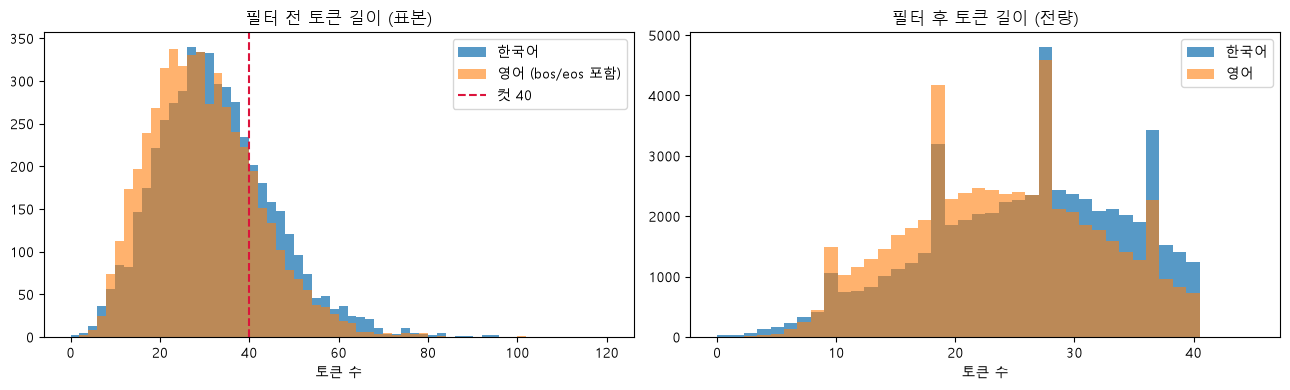

필터 후 한국어 mean 25.9 / max 40
필터 후 영어   mean 24.0 / max 40

[ 라운드트립 — 원문 -> 복원 ]
  원문   : 개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?
  복원   : 개인 용 컴퓨터 사용 의 상당 부분 은 이것 보다 뛰어날 수 있 느냐 ?
  영어   : much of personal computing is about can you top this ?
  원문   : 모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다 .
  복원   : 모든 광 마우스 와 마찬가지 로 이 광 마우스 도 책상 위 에 놓 는 마우스 패드 를 필요 로 하 지 않 는다 .
  영어   : so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable , wireless mouse .


In [30]:
src_len_all = np.array([len(encoder_tokenizer.encode(kor_morph[i])) for i in spm_sample_idx])
trg_len_all = np.array([len(decoder_tokenizer.encode(eng_text[i])) + 2 for i in spm_sample_idx])
src_len_kept = np.array([len(s) for s in kor_corpus])
trg_len_kept = np.array([len(s) for s in eng_corpus])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(src_len_all, bins=60, range=(0, 120), alpha=.75, label='한국어')
axes[0].hist(trg_len_all, bins=60, range=(0, 120), alpha=.6, label='영어 (bos/eos 포함)')
axes[0].axvline(MAX_LEN, color='crimson', ls='--', lw=1.5, label=f'컷 {MAX_LEN}')
axes[0].set_title('필터 전 토큰 길이 (표본)'); axes[0].set_xlabel('토큰 수'); axes[0].legend()

axes[1].hist(src_len_kept, bins=40, range=(0, 45), alpha=.75, label='한국어')
axes[1].hist(trg_len_kept, bins=40, range=(0, 45), alpha=.6, label='영어')
axes[1].set_title('필터 후 토큰 길이 (전량)'); axes[1].set_xlabel('토큰 수'); axes[1].legend()
plt.tight_layout(); plt.show()

print(f'필터 후 한국어 mean {src_len_kept.mean():.1f} / max {src_len_kept.max()}')
print(f'필터 후 영어   mean {trg_len_kept.mean():.1f} / max {trg_len_kept.max()}')

print('\n[ 라운드트립 — 원문 -> 복원 ]')
for j in range(2):
    i = kept_idx[j]
    print(f'  원문   : {kor_preprocessed[i]}')
    print(f'  복원   : {encoder_tokenizer.decode(kor_corpus[j])}')
    print(f'  영어   : {decoder_tokenizer.decode(eng_corpus[j])}')

---
# 6. 텐서 변환 & DataLoader

만든 id 시퀀스를 패딩해 텐서로 바꾸고, teacher forcing에 쓸 입력/라벨을 나눈다.

| 텐서 | 구성 | 용도 |
|---|---|---|
| `src` | 한국어 id + post-padding | Encoder 입력 |
| `trg_input` | `full[:-1]` + post-padding | Decoder 입력 |
| `trg_label` | `full[1:]` + post-padding | 정답 라벨 |


In [32]:
def pad_post(seqs, max_len, pad_id=0):
    """시퀀스 리스트를 뒤쪽 패딩해 (N, max_len) LongTensor 로 만든다."""
    out = torch.full((len(seqs), max_len), pad_id, dtype=torch.long)
    for i, s in enumerate(seqs):
        out[i, :len(s)] = torch.tensor(s, dtype=torch.long)
    return out


src_tensor = pad_post(kor_corpus, MAX_LEN, PAD_ID)
trg_input_tensor = pad_post([t[:-1] for t in eng_corpus], MAX_LEN, PAD_ID)   # <s> ... 마지막 단어
trg_label_tensor = pad_post([t[1:] for t in eng_corpus], MAX_LEN, PAD_ID)    # 첫 단어 ... </s>

print('src       :', tuple(src_tensor.shape))
print('trg_input :', tuple(trg_input_tensor.shape))
print('trg_label :', tuple(trg_label_tensor.shape))

src       : (55109, 40)
trg_input : (55109, 40)
trg_label : (55109, 40)


## 6-4. Dataset / DataLoader

In [33]:
BATCH_SIZE = 64

train_dataset = TensorDataset(src_tensor, trg_input_tensor, trg_label_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f'학습 샘플 : {len(train_dataset):,}')
print(f'배치 수   : {len(train_loader):,}  (batch_size={BATCH_SIZE})')

for src, trg_input, trg_label in train_loader:
    print('\n[ 배치 shape ]')
    print('  src       :', tuple(src.shape))
    print('  trg_input :', tuple(trg_input.shape))
    print('  trg_label :', tuple(trg_label.shape))
    break

학습 샘플 : 55,109
배치 수   : 862  (batch_size=64)

[ 배치 shape ]
  src       : (64, 40)
  trg_input : (64, 40)
  trg_label : (64, 40)


---
# 7. 모델 설계 — Encoder / BahdanauAttention / Decoder

## 바꿔야 하는 부분

| 항목 | 기존 | 이번 프로젝트 |
|---|---|---|
| `input_dim` / `output_dim` | `len(sp_tokenizer)` = 3,000 | `len(encoder_tokenizer)` / `len(decoder_tokenizer)` = **16,000** |
| `evaluate()` 입력 전처리 | 영어용 `preprocess_sentence` | **`preprocess_kor` → `ko_morphs` → `encoder_tokenizer.encode`** 로 교체 |

## Embedding Size / Hidden Size

| 후보 | emb | hid | 비고 |
|---|---|---|---|
| **A (채택)** | 256 | 512 | 하한 기준선 |
| B | 512 | 1024 | vocab 크기가 증가했으니 emb, hidden도 증가 |

§10-3의 비교 결과 **A를 채택**했다. B는 train loss를 24% 낮췄지만 번역은 4문장 중 3개에서 나빠졌고,
epoch 13에서 loss가 반등해 과적합이 먼저 왔다.

## 정규화 — dropout

A·B 두 실험이 모두 과적합을 가리켰다 (A는 K2가 **epoch 1에서 최고**, B는 지명 침투·수량 오류 악화).
병목은 용량이 아니므로 모델을 키우는 대신 정규화를 넣는다.


### 7-1. Attention · Encoder · Decoder

In [63]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)   # Encoder의 출력(각 소스 위치의 hidden state)에 곱해질 가중치
        self.W2 = nn.Linear(hidden_dim, hidden_dim)   # Decoder의 현재 hidden state에 곱해질 가중치
        self.v = nn.Linear(hidden_dim, 1, bias=False) # W1, W2를 거쳐 합쳐진 벡터를 스칼라 하나로 압축하는 레이어

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim). Decoder의 직전 시점 hidden state
        # encoder_outputs: (src_len, batch_size, hidden_dim). Encoder가 모든 위치에서 낸 hidden state 전체

        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)


class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, dropout=0.0):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # GRU 가 단층이라 nn.GRU(dropout=...) 는 무시된다(경고만 뜬다).
        # 대신 임베딩 출력에 직접 건다.
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.dropout(self.embedding(src))  # (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)          # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden


class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention, dropout=0.0):
        super().__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN 에는 embedding 만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state 와 attention value 가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)
        # 임베딩 직후와 출력층 직전, 두 군데에 건다.
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)  /  hidden : (1, batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)
        input = input.unsqueeze(0)                      # (1, batch_size)
        embedded = self.dropout(self.embedding(input))  # (1, batch_size, emb_dim)

        # attention distribution 계산. decoder 의 이전 hidden state s_{t-1} 와 encoder 의 H 가 입력된다.
        a = self.attention(hidden[-1], encoder_outputs)  # (batch_size, src_len)

        # H 에 가중치를 부여해 attention value(context vector) 계산
        a = a.unsqueeze(1)                                  # (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)             # (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)                  # (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state 와 context vector 를 결합해 예측값 생성
        output = output.squeeze(0)    # (batch_size, hidden_dim)
        context = context.squeeze(0)  # (batch_size, hidden_dim)
        prediction = self.fc_out(self.dropout(torch.cat((output, context), dim=1)))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)

### 7-2. `Seq2SeqAttention`

`trg` 가 있으면 teacher forcing(학습), 없으면 `<s>` 부터 argmax 자기회귀 생성(추론)이다. 추론에서는 배치 전체가 `</s>` 에 도달하면 조기 종료한다.

In [64]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=MAX_LEN, bos_id=BOS_ID, eos_id=EOS_ID):
        # 학습에서는 trg_len 만큼, 추론에서는 max_len 까지 동적으로 생성한다.
        batch_size = src.shape[1]

        outputs = []      # 조기 종료를 위해 tensor 가 아닌 리스트로 모은다
        attentions = []   # 시각화를 위해 attention 저장

        encoder_outputs, hidden = self.encoder(src)   # t=1 의 hidden 은 Encoder 의 final state

        if trg is not None:
            for t in range(0, trg.shape[0]):
                input = trg[t]                        # teacher forcing: 정답을 다음 입력으로
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
        else:
            # 추론에는 정답이 없으므로 <s> 를 첫 입력으로 만든다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

                top1 = output.argmax(1)
                input = top1

                finished |= (top1 == eos_id)          # 배치 전체가 </s> 를 내면 종료
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)        # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

### 7-3. Embedding / Hidden 크기 — 파라미터 수 비교

In [65]:
input_dim = len(encoder_tokenizer)
output_dim = len(decoder_tokenizer)


def build_model(emb_dim, hid_dim, dropout=0.0, to_device=None):
    """후보 구성으로 모델 하나를 만든다. (dropout 은 파라미터 수에 영향이 없다)"""
    encoder = Encoder(input_dim, emb_dim, hid_dim, dropout)
    attention = BahdanauAttention(hid_dim)
    decoder = Decoder(output_dim, emb_dim, hid_dim, attention, dropout)
    model = Seq2SeqAttention(encoder, decoder, to_device or torch.device('cpu'))
    return model.to(to_device) if to_device else model


CANDIDATES = [('A (기준)', 256, 512), ('B', 512, 1024)]

rows = []
for name, e, h in CANDIDATES:
    m = build_model(e, h)
    total = sum(p.numel() for p in m.parameters() if p.requires_grad)
    out_layer = m.decoder.fc_out.weight.numel() + m.decoder.fc_out.bias.numel()
    rows.append({'후보': name, 'emb': e, 'hid': h,
                 '전체 파라미터': f'{total / 1e6:.1f}M',
                 '출력층': f'{out_layer / 1e6:.1f}M',
                 '출력층 비중': f'{out_layer / total:.0%}'})
    del m

display(pd.DataFrame(rows))

,후보,emb,hid,전체 파라미터,출력층,출력층 비중
0,A (기준),256,512,27.5M,16.4M,60%
1,B,512,1024,60.7M,32.8M,54%


### 7-4. 모델 생성

In [66]:
# §10-3 비교 결과 A 채택. 과적합 완화를 위해 dropout 을 건다.
EMB_DIM = 256
HID_DIM = 512
DROPOUT = 0.3

model = build_model(EMB_DIM, HID_DIM, dropout=DROPOUT, to_device=device)
print(model)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n학습 파라미터 : {n_params:,} ({n_params / 1e6:.1f}M)')
print(f'input_dim={input_dim:,}  output_dim={output_dim:,}  '
      f'emb={EMB_DIM}  hid={HID_DIM}  dropout={DROPOUT}')

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(16000, 256)
    (rnn): GRU(256, 512)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(16000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=16000, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)

학습 파라미터 : 27,483,264 (27.5M)
input_dim=16,000  output_dim=16,000  emb=256  hid=512  dropout=0.3


In [67]:
src_b, trg_in_b, trg_lb_b = next(iter(train_loader))

# DataLoader 는 (batch, seq) 로 주지만 모델은 (seq, batch) 를 기대한다.
src_b = src_b.transpose(0, 1).to(device)
trg_in_b = trg_in_b.transpose(0, 1).to(device)
src_len, batch_size = src_b.shape
trg_len = trg_in_b.shape[0]

model.eval()
with torch.no_grad():
    # 1) 학습 경로 — teacher forcing
    outputs, attentions = model(src_b, trg_in_b)
    print('[ 학습 경로 ]')
    print('  outputs    :', tuple(outputs.shape))
    print('  attentions :', tuple(attentions.shape))
    assert outputs.shape == (trg_len, batch_size, output_dim)
    assert attentions.shape == (trg_len, batch_size, src_len)

    # attention 은 소스 위치에 대한 확률분포이므로 행 합이 1이어야 한다.
    assert torch.allclose(attentions.sum(dim=2), torch.ones(trg_len, batch_size, device=device), atol=1e-4)
    print('  attention 행 합 = 1')

    # 2) 추론 경로 — trg 없이 <s> 부터 생성, </s> 도달 시 조기 종료
    outputs_i, attentions_i = model(src_b[:, :4])
    print('\n[ 추론 경로 ]')
    print('  outputs    :', tuple(outputs_i.shape))
    print('  attentions :', tuple(attentions_i.shape))
    assert outputs_i.shape[1] == 4 and outputs_i.shape[2] == output_dim
    assert outputs_i.shape[0] <= MAX_LEN

[ 학습 경로 ]
  outputs    : (40, 64, 16000)
  attentions : (40, 64, 40)
  attention 행 합 = 1

[ 추론 경로 ]
  outputs    : (40, 4, 16000)
  attentions : (40, 4, 40)


---
# 8. 훈련

### 8-1. Optimizer & Loss

In [68]:
WEIGHT_DECAY = 1e-5

# weight_decay 는 가중치가 커지는 것에 벌점을 준다.
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=WEIGHT_DECAY)

# ignore_index=PAD_ID 가 패딩 마스킹이다.
# 이걸 빼면 라벨의 40%가 <pad> 라서 모델이 <pad> 만 뱉어도 loss 가 낮아진다.
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

print('optimizer :', type(optimizer).__name__,
      '| lr =', optimizer.param_groups[0]['lr'],
      '| weight_decay =', optimizer.param_groups[0]['weight_decay'])
print('criterion :', criterion, '| ignore_index =', PAD_ID)

# 마스킹이 실제로 동작하는지 확인 — 라벨 중 <pad> 비율
pad_ratio = (trg_label_tensor == PAD_ID).float().mean().item()
print(f'\n라벨 자리의 <pad> 비율 : {pad_ratio:.1%}')

optimizer : AdamW | lr = 0.001 | weight_decay = 1e-05
criterion : CrossEntropyLoss() | ignore_index = 0

라벨 자리의 <pad> 비율 : 42.5%


### 8-2. `train_step()`

In [69]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    """한 epoch 을 학습하고 평균 loss 를 돌려준다."""
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f'Epoch {epoch + 1}', leave=True)

    for src, trg_input, trg_label in progress_bar:
        src, trg_input, trg_label = src.to(device), trg_input.to(device), trg_label.to(device)

        # DataLoader 는 (batch, seq) 배치를 주지만, 모델/Encoder/Decoder 는 (seq, batch) 를 기대한다.
        # 전치하지 않으면 batch 와 seq 축이 뒤바뀐 채 (오류 없이) 잘못 학습된다.
        src = src.transpose(0, 1)
        trg_input = trg_input.transpose(0, 1)
        trg_label = trg_label.transpose(0, 1)

        optimizer.zero_grad()

        outputs, _ = model(src, trg_input)   # teacher forcing

        # (trg_len, batch_size, output_dim) -> (trg_len * batch_size, output_dim)
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)   # gradient explosion 방지

        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

---
# 9. 훈련 실행 + 매 epoch 예문 번역

- 매 epoch 4문장을 전부 번역해 기록한다.
- 매 epoch 체크포인트를 저장한다. 고른 epoch의 가중치를 다시 불러와 Attention Map을 그린다.

### 참고 제출 예시

```
K1) 오바마는 대통령이다.           E1) obama is the president . <end>
K2) 시민들은 도시 속에 산다.        E2) people are victims of the city . <end>
K3) 커피는 필요 없다.              E3) the price is not enough . <end>
K4) 일곱 명의 사망자가 발생했다.     E4) seven people have died . <end>
```

## 9-1. 예문 번역 함수

In [70]:
TEST_SENTENCES = [
    '오바마는 대통령이다.',
    '시민들은 도시 속에 산다.',
    '커피는 필요 없다.',
    '일곱 명의 사망자가 발생했다.',
]


def translate_sentence(sentence, model, max_len=MAX_LEN):
    """한국어 문장 하나를 번역한다.

    Returns:
        text       : 디코딩된 영어 문장 (</s> 로 끝났으면 ' <end>' 를 붙인다)
        pieces     : 생성된 subword 조각 — Attention Map 의 y축 라벨
        src_pieces : 인코더가 실제로 소비한 조각 — x축 라벨
        attention  : (생성 길이, 소스 길이) numpy 배열
    """
    was_training = model.training
    model.eval()

    # 학습 경로와 동일한 순서
    morphed = ' '.join(ko_morphs(preprocess_kor(sentence)))
    src_ids = encoder_tokenizer.encode(morphed)[:max_len]
    src_pieces = encoder_tokenizer.encode(morphed, out_type=str)[:max_len]

    # 문장이 하나뿐이라 패딩하지 않는다.
    src = torch.tensor(src_ids, dtype=torch.long, device=device).unsqueeze(1)  # (src_len, 1)

    with torch.no_grad():
        outputs, attentions = model(src, max_len=max_len, bos_id=BOS_ID, eos_id=EOS_ID)

    pred_ids = outputs.argmax(2).squeeze(1).tolist()
    hit_eos = EOS_ID in pred_ids
    if hit_eos:
        pred_ids = pred_ids[:pred_ids.index(EOS_ID)]      # </s> 이후는 버린다

    text = decoder_tokenizer.decode(pred_ids) + (' <end>' if hit_eos else '')
    pieces = [decoder_tokenizer.id_to_piece(i) for i in pred_ids]
    attention = attentions.squeeze(1).cpu().numpy()[:len(pred_ids), :len(src_pieces)]

    if was_training:
        model.train()

    return text, pieces, src_pieces, attention

## 9-2. 1 epoch 실측

1 epoch의 결과로 `EPOCHS`와 모델 크기(A/B)를 확정한다.

In [71]:
CKPT_DIR = os.path.join(DATA_DIR, 'ckpt')
os.makedirs(CKPT_DIR, exist_ok=True)

history = []


def run_epoch(epoch):
    """1 epoch 학습 -> 예문 4개 번역 -> 체크포인트 저장."""
    t0 = time.time()
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    elapsed = time.time() - t0

    outs = [translate_sentence(s, model)[0] for s in TEST_SENTENCES]

    print(f'Epoch {epoch + 1:>2}  Train Loss {train_loss:.4f}  ({elapsed:.0f}s)')
    for s, o in zip(TEST_SENTENCES, outs):
        print(f'    {s:<20} -> {o}')

    # best case 를 나중에 재현하려면 매 epoch 저장이 필요하다.
    torch.save(model.state_dict(), os.path.join(CKPT_DIR, f'epoch{epoch + 1:02d}.pt'))
    history.append({'epoch': epoch + 1, 'loss': train_loss, 'sec': elapsed, 'outputs': outs})
    return elapsed


sec = run_epoch(0)

print(f'\n1 epoch = {sec:.0f}s')
for e in (10, 20, 30):
    print(f'  {e:>2} epoch 예상 : {sec * e / 60:.0f}분')
ckpt_mb = os.path.getsize(os.path.join(CKPT_DIR, 'epoch01.pt')) / 1e6
print(f'체크포인트 1개 {ckpt_mb:.0f}MB  ->  20 epoch 이면 {ckpt_mb * 20 / 1000:.1f}GB')

Epoch 1: 100%|██████████| 862/862 [02:59<00:00,  4.81it/s, loss=5.6] 


Epoch  1  Train Loss 5.7259  (179s)
    오바마는 대통령이다.          -> obama's president elect obama said he would obama the president's president . <end>
    시민들은 도시 속에 산다.       -> they were able to find the bodies of the most important of the most famous of the most famous of the most famous . <end>
    커피는 필요 없다.           -> there was no reason for the first time , but he said there was no evidence . <end>
    일곱 명의 사망자가 발생했다.     -> the death toll in the central district of the capital , killing at least 20 people were injured . <end>

1 epoch = 179s
  10 epoch 예상 : 30분
  20 epoch 예상 : 60분
  30 epoch 예상 : 90분
체크포인트 1개 110MB  ->  20 epoch 이면 2.2GB


## 9-3. 본 학습

In [72]:
EPOCHS = 15

for epoch in range(len(history), EPOCHS):
    run_epoch(epoch)
    print()

print(f'총 {len(history)} epoch 완료 · 누적 {sum(h["sec"] for h in history) / 60:.0f}분')

Epoch 2: 100%|██████████| 862/862 [03:07<00:00,  4.59it/s, loss=4.62]


Epoch  2  Train Loss 4.8166  (188s)
    오바마는 대통령이다.          -> obama's president elect obama is the president of the president elect obama's president , obama said . <end>
    시민들은 도시 속에 산다.       -> they accuse the most of the most famous in the town of the town of the city of the town of the city of the town of the city . <end>
    커피는 필요 없다.           -> we cannot do not need to do not need to do not need to do anything . <end>
    일곱 명의 사망자가 발생했다.     -> the death toll was killed in the attack , killing at least 20 people dead , said sunday . <end>



Epoch 3: 100%|██████████| 862/862 [03:10<00:00,  4.52it/s, loss=4.8] 


Epoch  3  Train Loss 4.3377  (191s)
    오바마는 대통령이다.          -> obama's president elect obama is obama , said obama president obama , who is obama , said obama president obama , who is obama , said obama . <end>
    시민들은 도시 속에 산다.       -> they were also found in cities cities cities cities cities in cities cities cities cities cities . <end>
    커피는 필요 없다.           -> it is no stranger for the need to make sure that we need to do not need to do anything . <end>
    일곱 명의 사망자가 발생했다.     -> the death toll in the death toll , killing at least 20 people , were killed in the clashes , the associated press reported . <end>



Epoch 4: 100%|██████████| 862/862 [03:11<00:00,  4.50it/s, loss=4.72]


...

Epoch 13  Train Loss 2.9582  (170s)
    오바마는 대통령이다.          -> obama is president obama , who is obama , obama , is obama , said president obama , who is president obama . <end>
    시민들은 도시 속에 산다.       -> citizens , the citizens of cities , city , in town , cities in cities , cities in cities . <end>
    커피는 필요 없다.           -> coffee coffee coffee need need need to need for treatment , but coffee need need need to do little need to need . <end>
    일곱 명의 사망자가 발생했다.     -> the death toll from the scene showed that the death toll was killed when the death toll was killed , when the death toll was killed . <end>



Epoch 14: 100%|██████████| 862/862 [02:47<00:00,  5.14it/s, loss=3.53]


Epoch 14  Train Loss 2.9127  (168s)
    오바마는 대통령이다.          -> obama is president obama , who is obama , obama , is president obama's presidency , president obama said . <end>
    시민들은 도시 속에 산다.       -> citizens citizens in cities towns town of inner city towns in cities , city . <end>
    커피는 필요 없다.           -> coffee coffee coffee need to need need need need to need for the need to need for the need to need for need need need for need to need for need need need need for coffee . <end>
    일곱 명의 사망자가 발생했다.     -> the death toll was killed when the tornado slammed into the death toll , which killed at least seven people dead . <end>



Epoch 15: 100%|██████████| 862/862 [02:48<00:00,  5.12it/s, loss=2.6] 


Epoch 15  Train Loss 2.8742  (168s)
    오바마는 대통령이다.          -> obama is president obama , who is obama , said obama president barack obama is obama , but obama is president obama . <end>
    시민들은 도시 속에 산다.       -> citizens , the city's jewish cities , which farmers in town cities , inner city city , where the cities of the city's cities . <end>
    커피는 필요 없다.           -> coffee need to worry about the need for need to need for a fee to need for coffee . <end>
    일곱 명의 사망자가 발생했다.     -> the death toll at the scene showed the death toll in the death toll was killed when the death toll was killed in the bombing , which occurred at the scene . <end>

총 15 epoch 완료 · 누적 44분


## 9-4. 학습 곡선 & epoch별 번역 기록

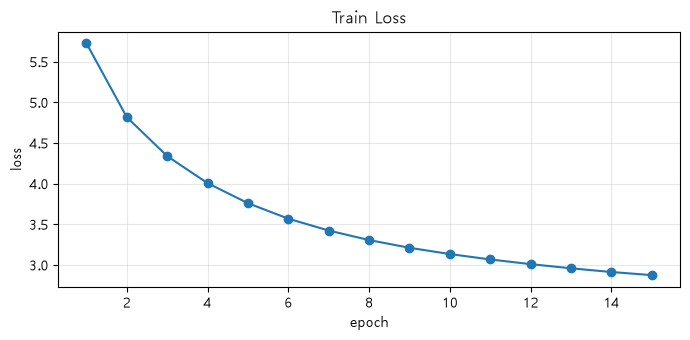

loss 5.7259 -> 2.8742  (49.8% 감소)


In [73]:
plt.figure(figsize=(7, 3.5))
plt.plot([h['epoch'] for h in history], [h['loss'] for h in history], marker='o')
plt.title('Train Loss'); plt.xlabel('epoch'); plt.ylabel('loss'); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

first, last = history[0]['loss'], history[-1]['loss']
print(f'loss {first:.4f} -> {last:.4f}  ({(first - last) / first:.1%} 감소)')

In [74]:
rows = []
for h in history:
    row = {'epoch': h['epoch'], 'loss': round(h['loss'], 4)}
    for k, o in enumerate(h['outputs'], 1):
        row[f'K{k}'] = o
    rows.append(row)

pd.set_option('display.max_colwidth', 70)
display(pd.DataFrame(rows))

print('K1 오바마는 대통령이다.   K2 시민들은 도시 속에 산다.')
print('K3 커피는 필요 없다.      K4 일곱 명의 사망자가 발생했다.')

,epoch,loss,K1,K2,K3,K4
0,1,5.7259,obama's president elect obama said he would obama the president's ...,they were able to find the bodies of the most important of the mos...,"there was no reason for the first time , but he said there was no ...","the death toll in the central district of the capital , killing at..."
1,2,4.8166,obama's president elect obama is the president of the president el...,they accuse the most of the most famous in the town of the town of...,we cannot do not need to do not need to do not need to do anything...,"the death toll was killed in the attack , killing at least 20 peop..."
2,3,4.3377,"obama's president elect obama is obama , said obama president obam...",they were also found in cities cities cities cities cities in citi...,it is no stranger for the need to make sure that we need to do not...,"the death toll in the death toll , killing at least 20 people , we..."
3,4,4.0055,"obama's president elect obama is obama , obama said . <end>",they are designed to see cities cities across the cities . <end>,"coffee , no need to need to need to need to need to need to the ne...","the death toll began friday , killing at least 26 people , and the..."
4,5,3.7589,"obama has countered president obama's president , obama said . <end>","they accuse the town of kisumu , where they were buried in cities ...",coffee need to need to need for a need to need to do anything nece...,"the death toll from the death toll in the death toll , which kille..."
5,6,3.5684,"obama is obama , he said obama is obama . <end>","they accuse the city of urban city in cities , where they were unl...",coffee need to need for need to need for a coffee need to need for...,the death toll from the death toll on monday killed dozens of peop...
6,7,3.4226,"obama is obama , he said . obama is a president obama . <end>","they accuse the city of daegu's cities in the city of daegu , wher...",coffee need to need need for coffee and need for the need to need ...,"the death toll from the death toll at yogyakarta's death toll , ki..."
7,8,3.3056,"obama has countered obama's presidency , obama said . <end>","they are in cities cities around the town of eldoret , where they ...",coffee need to need need to need to do not need to need to need fo...,the death toll of the death toll was killed in the wake of the dea...
8,9,3.2105,"obama is president obama , who is obama , obama said obama wishes ...",citizens citizens in cities cities across cities cities across cit...,coffee need to need need for need for need for need for need for n...,"the death toll from the death toll of the death toll , which kille..."
9,10,3.1334,"obama is president obama , who is obama , obama said . <end>","citizens citizens citizens in cities city in cities city , where t...",coffee need to need need to do so need to need need to do without ...,"the death toll from the death toll at the scene , which killed nea..."


K1 오바마는 대통령이다.   K2 시민들은 도시 속에 산다.
K3 커피는 필요 없다.      K4 일곱 명의 사망자가 발생했다.


---
# 10. 실험

## 10-1. 모델 크기 비교 — A vs B

| | A | B |
|---|---|---|
| emb / hid | 256 / 512 | 512 / 1024 |
| 파라미터 | 27.5M | **60.7M** (2.2배) |
| epoch | 15 | 15 |
| epoch당 시간 | 85s (후반 188s로 늘어남) | 213~234s (**2.6배**) |
| 총 학습 시간 | 31분 | **55분** |
| 체크포인트 1개 | 110MB | **243MB** (15개 3.4GB) |
| train loss | 3.9709 → 0.5451 (86.3%) | 5.1287 → **0.4157** (91.9%) |
| loss 최저 epoch | 15 (끝까지 단조 감소) | **13** (0.4113) — 14·15에서 반등 |

### 판정: **A 채택**

B는 train loss를 A보다 24% 낮췄지만 **번역 품질은 나아지지 않았다. 4문장 중 3문장에서 오히려 나빠졌다.**

| 예문 | A 최고 | B 최고 | 판정 |
|---|---|---|---|
| K1 오바마는 대통령이다. | ep5 `obama is a president , obama said , obviously , obama is a president .` | ep4 `obama , the illinois senator who is the president , is in office .` | **B** — 유일하게 문법이 온전한 완결 문장 |
| K2 시민들은 도시 속에 산다. | ep1 `citizens , however , they are in the streets of the city , where they are homeless in the city .` | ep6 `in city of cities , they are paraded in cities , city towns .` | **A** |
| K3 커피는 필요 없다. | ep11 `coffee is necessary to ensure no one needs there .` | ep6 `coffee is needed no need for coffee , especially for children .` | **A** (근소) |
| K4 일곱 명의 사망자가 발생했다. | ep8 `seven people were killed in the hospital in the capital , bangkok .` | ep10 `seven people were killed in the death toll monday , the associated press reported friday killed three people in the insurgency .` | **A** |

### B가 나빠진 원인 — 용량이 아니라 과적합이 병목이다


| 증상 | A | B | 결과 |
|---|---|---|---|
| 같은 어절 반복 | `the city city` | `city city towns in cities city's city streets in downtown district city` · ep1 `coffee coffee no coffee coffee coffee…` · ep2 `need need need need…` | **악화** |
| 문장을 못 끝냄 | K1이 15~25 토큰 | K1이 ep4·ep12에서 짧고 완결됨 | 개선 |
| 훈련 데이터 고유명사 침투 | `daegu` `bangkok` `lee myung bak` | `daegu` `pyeongchang` `nashville` `gangwon` `utah` `missouri` `delusuan` | **악화** |
| 수량 정확도 (K4) | ep8~14 내내 `seven` 유지 | ep12 `some 205 people` · ep13·14 `some 20 people` — **일곱을 놓침** | **악화** |

**loss 곡선이 결정적이다.** B는 epoch 13(0.4113)에서 바닥을 치고 14(0.4122)·15(0.4157)에서 반등했다.
A는 15 epoch까지 단조 감소했다. 데이터가 55,109쌍뿐인데 60.7M은 과하다는 직접 증거다.
**모델이 번역을 배우는 대신 훈련 문장을 외우기 시작한 지점**이 loss 곡선에 그대로 찍혔다.

### 채택 근거 요약

1. **번역 품질** — 4문장 중 A 우위 3, B 우위 1
2. **비용** — B는 epoch당 2.6배 느리고 체크포인트가 2.2배 크다
3. **수렴 양상** — B는 13 epoch에서 과적합 시작, A는 아직 여유

## 10-2 번역 품질 향상 - 과적합 완화

"병목은 용량이 아니라 과적합"이라고 진단하고, A 구성에 정규화를 걸었다.

| | A (정규화 없음) | **A + 정규화** |
|---|---|---|
| emb / hid | 256 / 512 | 256 / 512 (동일) |
| dropout | — | **0.3** (인코더 임베딩 · 디코더 임베딩 · `fc_out` 직전) |
| optimizer | Adam | **AdamW** (`weight_decay=1e-5`) |
| epoch | 15 | 15 |
| 총 시간 | 31분 | 44분 |
| train loss | 3.9709 → **0.5451** (86.3%) | 5.7259 → **2.8742** (49.8%) |
| loss 곡선 | 15까지 단조 감소 | 15까지 단조 감소, **기울기 완만 · 미수렴** (14→15 −0.039) |

### 판정: 개선되지 않았다. **4문장 모두 나빠졌다.**

| 예문 | A (정규화 없음) 최고 | A + 정규화 최고 | 판정 |
|---|---|---|---|
| K1 오바마는 대통령이다. | ep5 `obama is a president , obama said , obviously , obama is a president .` | ep10 `obama is president obama , who is obama , obama said .` | **A** |
| K2 시민들은 도시 속에 산다. | ep1 `citizens , however , they are in the streets of the city , where they are homeless in the city .` | ep10 `citizens citizens citizens in cities city in cities city , where they were barricaded .` | **A** (큰 차이) |
| K3 커피는 필요 없다. | ep11 `coffee is necessary to ensure no one needs there .` | ep15 `coffee need to worry about the need for need to need for a fee to need for coffee .` | **A** (큰 차이) |
| K4 일곱 명의 사망자가 발생했다. | ep8 `seven people were killed in the hospital in the capital , bangkok .` | ep14 `the death toll was killed when the tornado slammed into the death toll , which killed at least seven people dead .` | **A** |

### 무엇이 나빠졌나

**1. 반복 루프가 심해졌다.** 정규화 이전에는 없던 수준의 붕괴가 나온다.

```
ep3  K2 : they were also found in cities cities cities cities cities in cities cities cities cities cities .
ep9  K2 : citizens citizens in cities cities across cities cities across cities cities across cities .
ep6  K3 : coffee need to need for need to need for a coffee need to need for the need to need for …
ep6  K1 : obama is obama , he said obama is obama .
```

**2. `</s>` 를 못 만들어 `max_len` 까지 가는 경우가 생겼다.**

| 실행 | 40 토큰을 다 쓰고 `<end>` 없이 끊긴 출력 |
|---|---|
| A (정규화 없음) | 0건 |
| B | 1건 |
| **A + 정규화** | **3건** (ep6·ep12 K3, ep9 K4) |

**3. 과적합 지표는 줄지 않았다.** 막으려던 훈련 데이터 고유명사 침투가 그대로다 —
`daegu`(ep7·12) `kisumu`(ep5) `eldoret`(ep8) `yogyakarta`(ep7) `jewish`(ep12·15).

**4. K4의 수량이 무너졌다.** 정규화 이전 A는 ep8~14 내내 `seven` 을 유지했는데,
정규화 버전은 15 epoch 중 ep14 한 번만 `seven` 이 나오고 나머지는
`20` `26` `170` `3000` `4000` `17` 로 흩어진다.

### 원인 — dropout 0.3 이 과했다.

단층 GRU에 dropout 0.3을 걸면 디코더 hidden이 매 스텝 노이즈를 받아 문맥을 유지하지 못한다.
그 결과가 위의 반복 루프와 `</s>` 실패다. **정규화가 반복 루프를 오히려 만들어냈다.**

### 세 실험이 함께 가리키는 것

| 실험 | 조건 | 반복 루프 |
|---|---|---|
| A | 27.5M, 정규화 없음 | 있음 |
| B | 60.7M (**용량 2.2배**) | **악화** |
| A + 정규화 | 27.5M + dropout 0.3 (**정규화 추가**) | **악화** |

**용량을 키워도, 정규화를 걸어도 반복 루프는 나빠졌다.**

| 원인 후보 | 근거 |
|---|---|
| **greedy decoding** | 매 스텝 argmax만 취하므로 한 번 고빈도 토큰(`city` `need` `death toll`)에 들어가면 빠져나올 경로가 없다 |
| **teacher forcing 100%** | 학습 중에는 늘 정답을 입력받아, 자기가 만든 출력을 다시 입력받는 추론 상황을 한 번도 겪지 않는다 (exposure bias) |

### 다음 시도

1. **beam search 또는 repetition penalty** — 반복 루프를 직접 겨냥한다. 재학습이 필요 없어 가장 싸다
2. **dropout 0.1~0.15 + epoch 30** — 정규화를 유지하려면 이 조합. 지금은 underfit이라 epoch이 부족하다
3. **scheduled sampling** (teacher forcing ratio를 1.0에서 점차 낮춤) — exposure bias를 직접 겨냥

---
# 11 결과


| | 값 |
|---|---|
| 선택한 epoch | **8** (train loss 1.1069) |
| 실행 조건 | A (256/512) · **dropout 없음** · 15 epoch |
| 고른 이유 | 4문장이 모두 주제 위에 있고, K4가 목표 문장과 사실상 일치한다. 이후 epoch은 loss가 더 낮지만 K2·K3이 무너진다 |

```
K1) 오바마는 대통령이다.          E1) obama is making president obama's president , while obama has been president obama . <end>
K2) 시민들은 도시 속에 산다.       E2) the korean city in somalia city citizens will eventually be up in the zone around the town of the town city . <end>
K3) 커피는 필요 없다.             E3) coffee is unlikely to win the city needs , but there is no room of coffee . <end>
K4) 일곱 명의 사망자가 발생했다.    E4) seven people were killed in the hospital in the capital , bangkok . <end>
```

---
# 12. 회고


## 배운 점
- 병렬 코퍼스에서 `set`으로 중복을 제거할 때 쌍을 유지하는 방법을 배웠다.
- EDA로 학습 교재 사이트 UI 문구, 어휘 풀이 나열, 소스에 정답이 그대로 들어간 문장 같은 노이즈를 직접 찾아 제거하면서, 전처리는 감이 아니라 실측 수치로 결정해야 한다는 것을 배웠다. 같은 이유로 SentencePiece의 `character_coverage`를 0.9995로 두면 한국어처럼 문자 종류가 적은 언어에서 오히려 `<unk>`가 생긴다는 것도 라운드트립 검증으로 직접 확인했다.
- 모델을 키워도(B), 정규화를 추가해도(dropout) 번역 품질이 개선되지 않고 오히려 반복 루프가 심해졌다. train loss는 두 경우 모두에서 유의미하게 움직였지만 그 방향이 품질과는 무관했다. 서로 반대 방향의 두 실험이 모두 실패했다는 사실 자체가, 원인이 모델 용량이 아니라 디코딩 방식(greedy)이나 학습 방식(teacher forcing)에 있다는 신호라는 것을 이번에 배웠다.


## 아쉬운 점 / 한계
- 검증셋을 두지 않아 일반화 성능을 수치로 말할 수 없다.
- teacher forcing 100%, greedy decoding으로 인한 반복 루프가 남아 있다. 재학습 없이 시도할 수 있는 beam search나 repetition penalty를 시도하지 못했고, scheduled sampling을 적용했을 때 어느 정도 성능이 향상되는지도 확인하지 못했다.
- 매 실행마다 체크포인트 파일명이 `epochNN.pt`로 고정돼 있어, 새 구성(B, 정규화)을 돌릴 때마다 이전 실행의 체크포인트가 덮어써졌다. 구성 이름을 파일명에 포함시켰어야 했다.